<a href="https://colab.research.google.com/github/deborahpongeluppe/Deborahpongeluppe/blob/main/theWelch's_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded = files.upload()

Saving moved_project_sql_result_01.csv to moved_project_sql_result_01.csv


In [3]:
from google.colab import files
uploaded = files.upload()

Saving moved_project_sql_result_04.csv to moved_project_sql_result_04.csv


In [4]:
from google.colab import files
uploaded = files.upload()

Saving moved_project_sql_result_07.csv to moved_project_sql_result_07.csv


In [5]:
df_trips = pd.read_csv('moved_project_sql_result_01.csv')
df_dropoffs = pd.read_csv('moved_project_sql_result_04.csv')
df_ohare = pd.read_csv('moved_project_sql_result_07.csv')

In [6]:
print(df_trips.head())
print(df_trips.info())

                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                 Medallion Leasin         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None


In [7]:
print(df_dropoffs.head())
print(df_dropoffs.info())

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
None


In [8]:
print(df_ohare.head())
print(df_ohare.info())

              start_ts weather_conditions  duration_seconds
0  2017-11-25 16:00:00               Good            2410.0
1  2017-11-25 14:00:00               Good            1920.0
2  2017-11-25 12:00:00               Good            1543.0
3  2017-11-04 10:00:00               Good            2512.0
4  2017-11-11 07:00:00               Good            1440.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB
None


In [9]:
top_10_destinos = df_dropoffs.sort_values('average_trips', ascending=False).head(10)
print("Top 10 bairros mais populares como destino:")
print(top_10_destinos)

Top 10 bairros mais populares como destino:
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


An analysis of the top neighborhoods by destination reveals that the Loop ranks first with approximately 10,727 trips—serving as Chicago's financial district—while River North follows closely behind; these two areas are the most visited destinations.

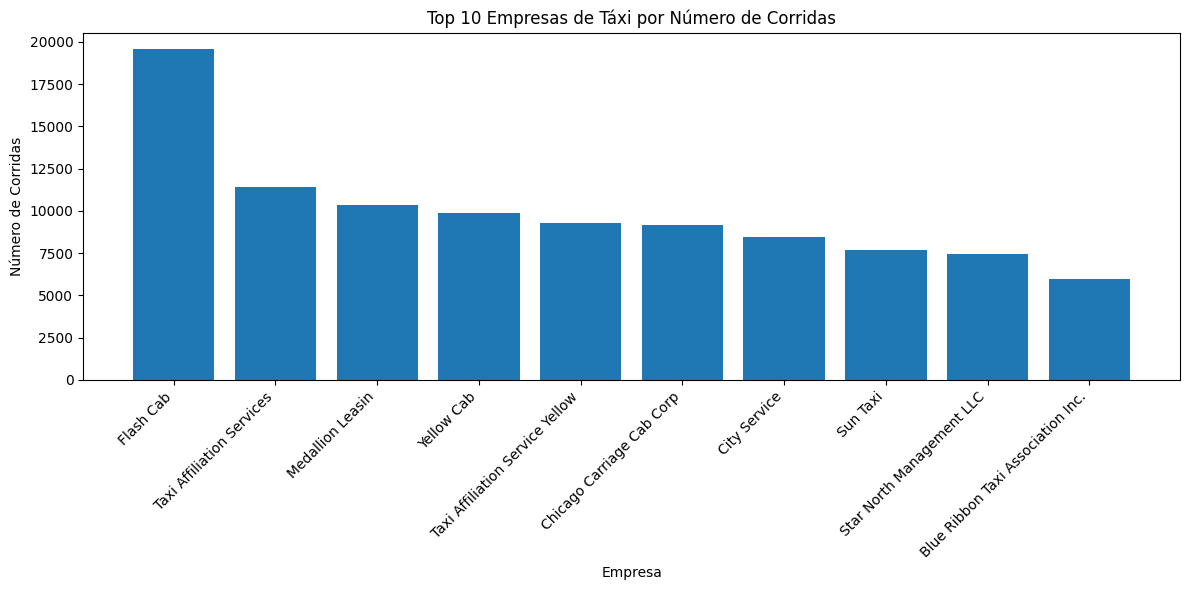

In [10]:
df_trips_sorted = df_trips.sort_values('trips_amount', ascending=False)
plt.figure(figsize=(12, 6))
plt.bar(df_trips_sorted['company_name'][:10], df_trips_sorted['trips_amount'][:10])
plt.title('Top 10 Empresas de Táxi por Número de Corridas')
plt.xlabel('Empresa')
plt.ylabel('Número de Corridas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This chart was created to show the top 10 taxi companies by number of trips. It is evident that Flash Cab has the highest number of trips, with a significant margin over the others; however, from the second-ranked company onwards, the differences are minimal, meaning the trip volumes among the remaining companies are quite similar.

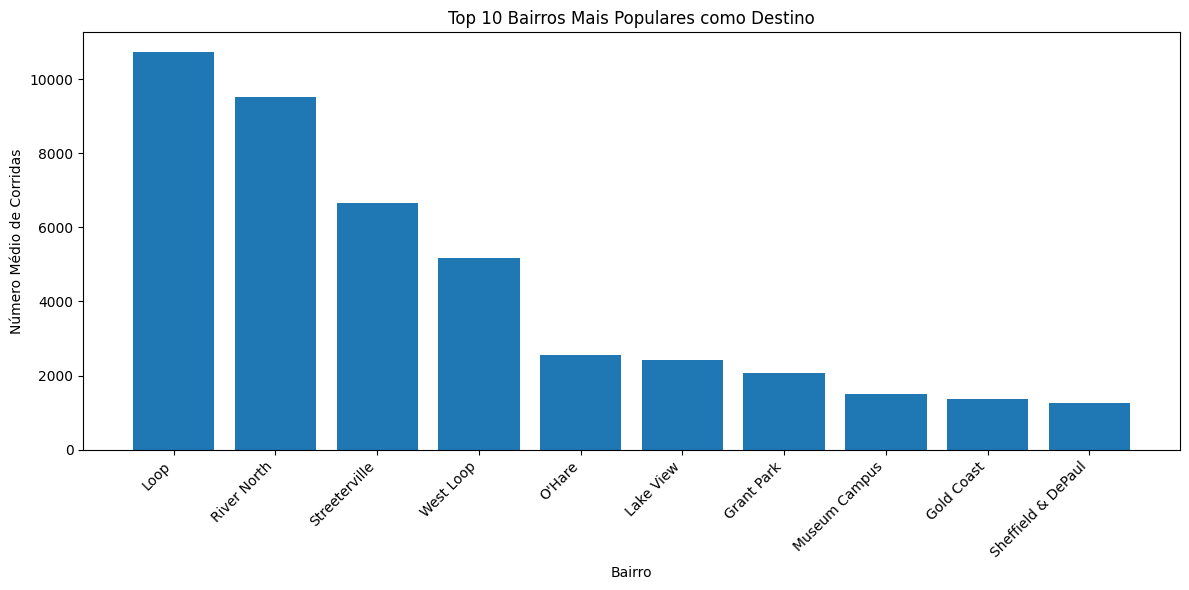

In [11]:
plt.figure(figsize=(12, 6))
plt.bar(top_10_destinos['dropoff_location_name'], top_10_destinos['average_trips'])
plt.title('Top 10 Bairros Mais Populares como Destino')
plt.xlabel('Bairro')
plt.ylabel('Número Médio de Corridas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This chart aims to visually illustrate the analysis presented just above regarding the neighborhoods with the highest number of trips ending there; we can see that the top four have very similar trip volumes, whereas from the fifth spot onwards, there is a significant drop in the number of trips, though the figures remain quite close among those neighborhoods.

In [12]:
df_ohare['start_ts'] = pd.to_datetime(df_ohare['start_ts'])
df_ohare['day_of_week'] = df_ohare['start_ts'].dt.day_name()
sabados_chuvosos = df_ohare[(df_ohare['day_of_week'] == 'Saturday') &
                           (df_ohare['weather_conditions'] == 'Bad')]
outros_casos = df_ohare[~((df_ohare['day_of_week'] == 'Saturday') &
                         (df_ohare['weather_conditions'] == 'Bad'))]
print(f"Sábados chuvosos: {len(sabados_chuvosos)} corridas")
print(f"Outros casos: {len(outros_casos)} corridas")
print(f"Total: {len(df_ohare)} corridas")

Sábados chuvosos: 180 corridas
Outros casos: 888 corridas
Total: 1068 corridas


In [13]:
duracoes_sabados_chuvosos = sabados_chuvosos['duration_seconds']
duracoes_outros_casos = outros_casos['duration_seconds']

print(f"Durações sábados chuvosos: {len(duracoes_sabados_chuvosos)} valores")
print(f"Durações outros casos: {len(duracoes_outros_casos)} valores")

Durações sábados chuvosos: 180 valores
Durações outros casos: 888 valores


In [14]:
print("=== SÁBADOS CHUVOSOS ===")
print(f"Média: {duracoes_sabados_chuvosos.mean():.2f} segundos")
print(f"Mediana: {duracoes_sabados_chuvosos.median():.2f} segundos")
print(f"Desvio padrão: {duracoes_sabados_chuvosos.std():.2f} segundos")

print("\n=== OUTROS CASOS ===")
print(f"Média: {duracoes_outros_casos.mean():.2f} segundos")
print(f"Mediana: {duracoes_outros_casos.median():.2f} segundos")
print(f"Desvio padrão: {duracoes_outros_casos.std():.2f} segundos")

=== SÁBADOS CHUVOSOS ===
Média: 2427.21 segundos
Mediana: 2540.00 segundos
Desvio padrão: 721.31 segundos

=== OUTROS CASOS ===
Média: 1999.68 segundos
Mediana: 1800.00 segundos
Desvio padrão: 759.20 segundos


In [15]:
var_bad = duracoes_sabados_chuvosos.var()
var_good = duracoes_outros_casos.var()

print("Variância dias chuvosos:", var_bad)
print("Variância dias bons:", var_good)
razao = var_good / var_bad
print(f"Razão entre variâncias: {razao:.2f}")

Variância dias chuvosos: 520294.08600248274
Variância dias bons: 576382.0096895089
Razão entre variâncias: 1.11


After performing the analysis of variance, the results are: variance for rainy days = 520,294.086002483, variance for good days = 576,382.009689509, and the variance ratio = 1.11. Although the ratio is 1.11 (close to 1.0), I opted for `equal_var=False` as a precaution. Given that we are comparing different weather conditions (rainy Saturdays versus other cases), it is reasonable to expect distinct variability patterns; the Welch test is more robust and does not assume equal variances, thereby ensuring reliable results.

In [16]:
from scipy import stats
t_statistic, p_value = stats.ttest_ind(duracoes_sabados_chuvosos, duracoes_outros_casos, equal_var=False)

print("=== RESULTADOS DO TESTE DE WELCH ===")
print(f"Estatística t: {t_statistic:.4f}")
print(f"Valor p: {p_value}")
print(f"Nível de significância (α): 0.05")
print("Teste utilizado: Teste de Welch (equal_var=False)")


=== RESULTADOS DO TESTE DE WELCH ===
Estatística t: 7.1860
Valor p: 6.738994326108734e-12
Nível de significância (α): 0.05
Teste utilizado: Teste de Welch (equal_var=False)


This hypothesis test was conducted as follows: the Null Hypothesis (H₀) was "The average duration of rides from the Loop to O'Hare does not change on rainy Saturdays," and the Alternative Hypothesis (H₁) was "The average duration of rides from the Loop to O'Hare changes on rainy Saturdays." The standard significance level of α = 0.05 was used, and a Welch's test was performed as the statistical test, given that the analysis involved comparing the means of two groups.
Statistical analysis was conducted comparing rainy Saturdays to other cases, examining the mean, median, and standard deviation for both groups. The results revealed a considerable difference in means: rides on rainy Saturdays took approximately 427.53 seconds longer—which translates to about 7 minutes—indicating an increase in travel time on rainy Saturdays.
Following the Welch's test—which yielded a t-statistic of 7.1860, a p-value of 6.738994326108734e-12, and a significance level (α) of 0.05—we can conclude that the mean duration is higher on rainy Saturdays. Since the p-value is less than 0.05 (meaning the probability of error is virtually zero), we reject the null hypothesis. Given this, we can conclude that rainy Saturdays do indeed increase travel time. After addressing the initial question posed by the test, it is important to devise strategies to ensure the smooth operation of the Zuber service. Since trips from the Loop to the airport take about seven minutes longer on Saturdays, passengers should be informed of this delay via the app to avoid the risk of missing their flights. It is also important to consider a fixed rate to account for this extra time, thereby providing the customer with price certainty. At the same time, to compensate drivers—who complete fewer trips due to the extended duration—the service rate must be fair, and incentives should be created to encourage them to accept these rides.